In [ ]:
# import library

In [68]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")
from matplotlib.pyplot import figure
import matplotlib
%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (12,8)
import numpy as np

In [65]:
# Read the data file:
df = pd.read_csv("movies.csv")

In [66]:
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


In [69]:
# Let see if there any missing data

for col in df.columns:
    pct_missing = np.mean(df[col].isnull())
    print('{} - {}%'.format(col , pct_missing))

name - 0.0%
rating - 0.010041731872717789%
genre - 0.0%
year - 0.0%
released - 0.0002608242044861763%
score - 0.0003912363067292645%
votes - 0.0003912363067292645%
director - 0.0%
writer - 0.0003912363067292645%
star - 0.00013041210224308815%
country - 0.0003912363067292645%
budget - 0.2831246739697444%
gross - 0.02464788732394366%
company - 0.002217005738132499%
runtime - 0.0005216484089723526%


In [20]:
# Data type for our columns
df.dtypes

name         object
rating       object
genre        object
year          int64
released     object
score       float64
votes       float64
director     object
writer       object
star         object
country      object
budget      float64
gross       float64
company      object
runtime     float64
dtype: object

In [21]:
# change data type of columns
df['budget'] = df['budget'].astype('Int64')

df['gross'] = df['gross'].astype('Int64')

In [22]:
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000,46998772,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000,58853106,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000,538375067,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000,83453539,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000,39846344,Orion Pictures,98.0


In [23]:
# Create correct year column

df['yearcorrect'] = df['released'].str.extract(r'(\d{4})')

In [24]:
df = df.sort_values(by = 'gross', inplace = False , ascending = False )

In [ ]:
# Budget high correlation
# Company high correlation

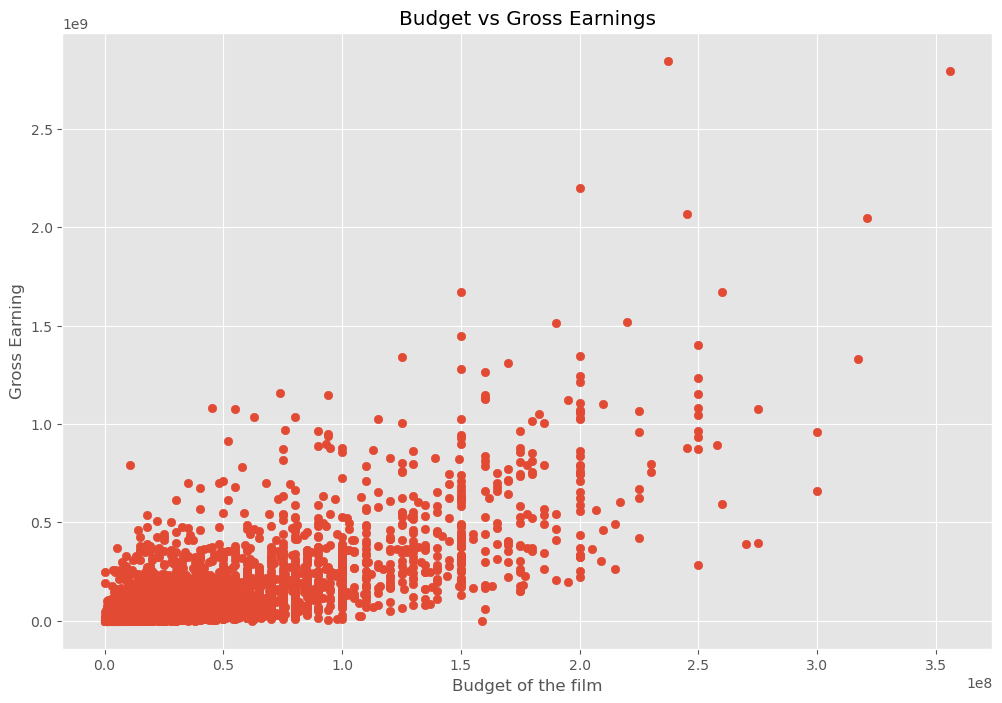

In [67]:
# scatter plot with budget vs gross

plt.scatter(x = df['budget'] , y = df['gross'])

plt.title("Budget vs Gross Earnings")

plt.xlabel("Budget of the film")
plt.ylabel("Gross Earning")

plt.show()


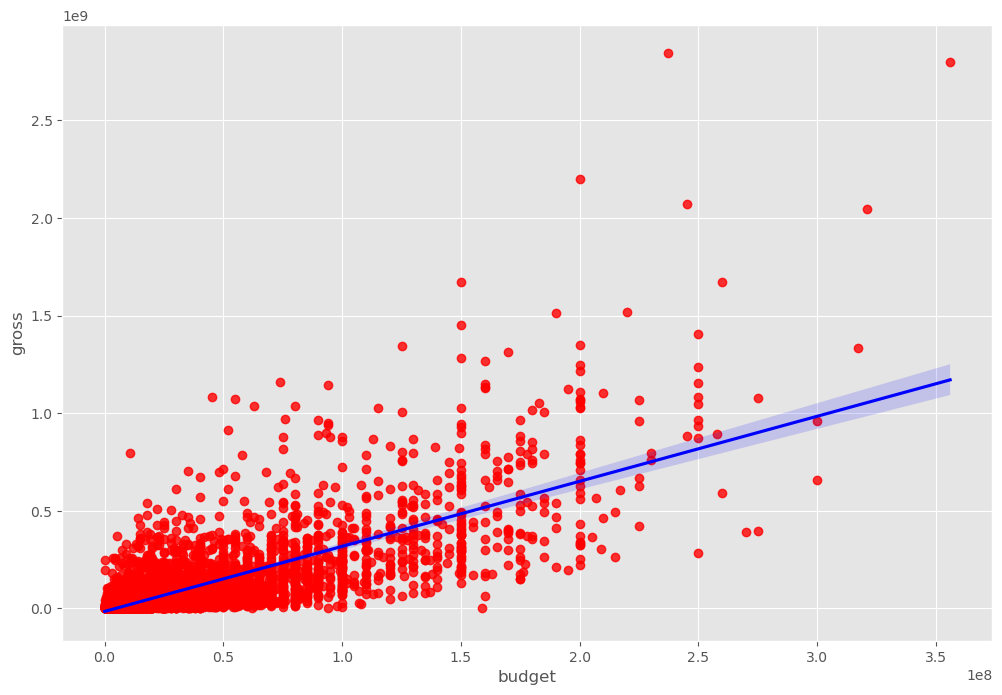

In [26]:
# Plot budget vs gross using seaborn

sns.regplot(x = 'budget' , y = 'gross' , data = df , scatter_kws = {'color':'red'} , line_kws = {'color':'blue'})
plt.show()

In [36]:
# Let's start looking at correlation
corr = df[['budget','gross','runtime','score','votes','year']].corr(method = 'pearson') #pearson , spearman

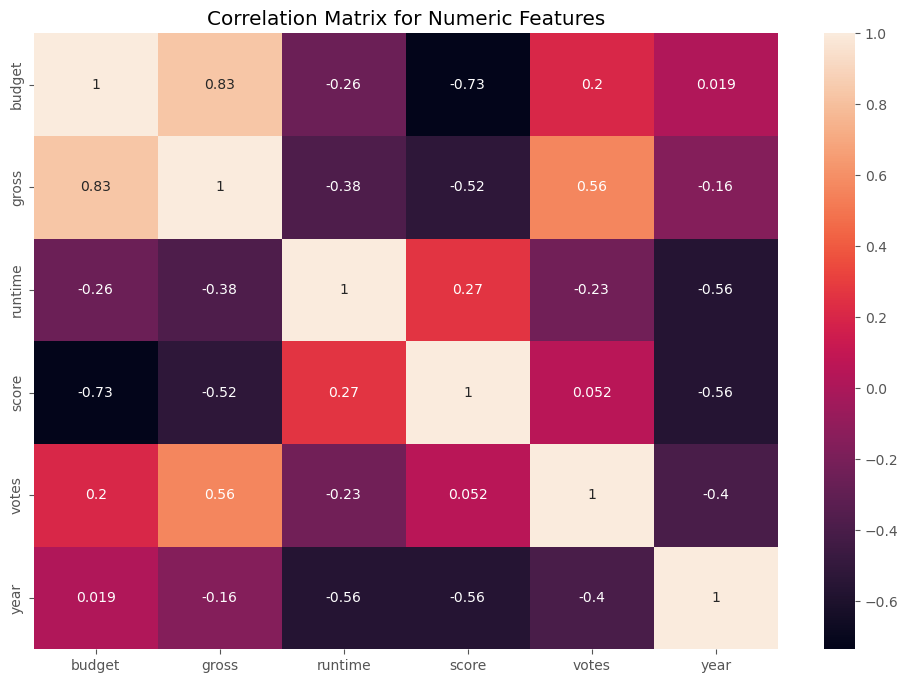

In [42]:
correlation_matrix = corr.corr(method = 'pearson')

plt.title("Correlation Matrix for Numeric Features")

plt.xlabel("Movie Features")
plt.ylabel("Movie Features")

sns.heatmap(correlation_matrix , annot = True)
plt.show()

In [43]:
# Look at company

df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,yearcorrect
5445,Avatar,PG-13,Action,2009,"December 18, 2009 (United States)",7.8,1100000.0,James Cameron,James Cameron,Sam Worthington,United States,237000000,2847246203,Twentieth Century Fox,162.0,2009
7445,Avengers: Endgame,PG-13,Action,2019,"April 26, 2019 (United States)",8.4,903000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,356000000,2797501328,Marvel Studios,181.0,2019
3045,Titanic,PG-13,Drama,1997,"December 19, 1997 (United States)",7.8,1100000.0,James Cameron,James Cameron,Leonardo DiCaprio,United States,200000000,2201647264,Twentieth Century Fox,194.0,1997
6663,Star Wars: Episode VII - The Force Awakens,PG-13,Action,2015,"December 18, 2015 (United States)",7.8,876000.0,J.J. Abrams,Lawrence Kasdan,Daisy Ridley,United States,245000000,2069521700,Lucasfilm,138.0,2015
7244,Avengers: Infinity War,PG-13,Action,2018,"April 27, 2018 (United States)",8.4,897000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,321000000,2048359754,Marvel Studios,149.0,2018


In [47]:
df_numerized = df

for col_name in df_numerized.columns:
    if df_numerized[col_name].dtype == 'object':
        df_numerized[col_name] = df_numerized[col_name].astype('category')
        df_numerized[col_name] = df_nymerized[col_name].cat.codes
df_numerized.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,yearcorrect
5445,533,5,0,2009,696,7.8,1100000.0,1155,1778,2334,55,237000000,2847246203,2253,162.0,29
7445,535,5,0,2019,183,8.4,903000.0,162,743,2241,55,356000000,2797501328,1606,181.0,39
3045,6896,5,6,1997,704,7.8,1100000.0,1155,1778,1595,55,200000000,2201647264,2253,194.0,17
6663,5144,5,0,2015,698,7.8,876000.0,1125,2550,524,55,245000000,2069521700,1540,138.0,35
7244,536,5,0,2018,192,8.4,897000.0,162,743,2241,55,321000000,2048359754,1606,149.0,38


In [53]:
corr = df_numerized[['budget','gross','runtime','score','votes','year','company','writer','star','genre','released']].corr(method = 'pearson') #pearson , spearman

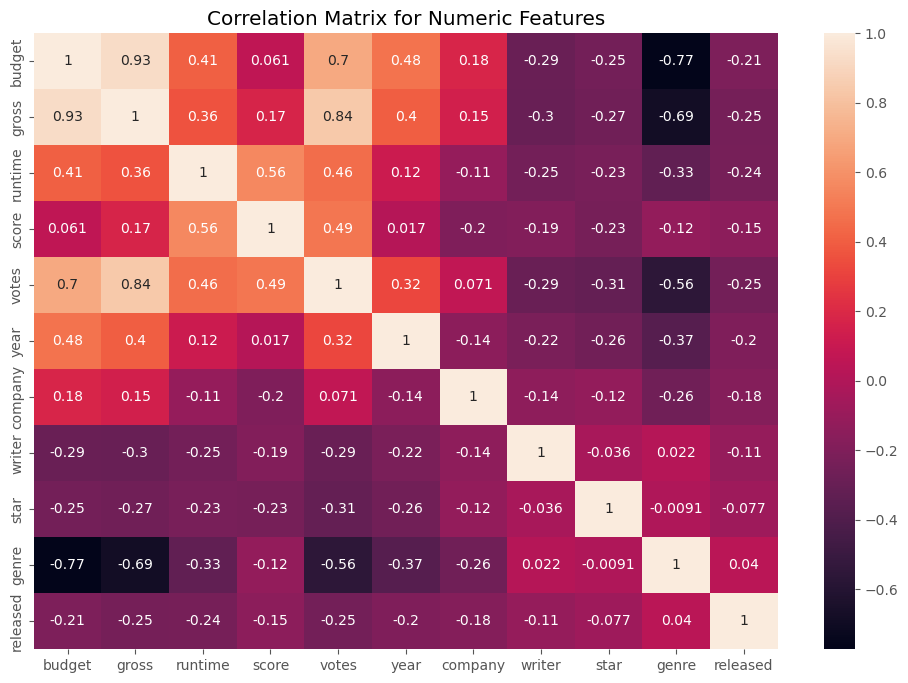

In [55]:
correlation_matrix = corr.corr(method = 'pearson')

plt.title("Correlation Matrix for Numeric Features")

plt.xlabel("Movie Features")
plt.ylabel("Movie Features")

sns.heatmap(correlation_matrix , annot = True)
plt.show()

In [54]:
corr

,budget,gross,runtime,score,votes,year,company,writer,star,genre,released
budget,1.000000,0.740395,0.320447,0.076254,0.442429,0.329321,0.173214,-0.039451,-0.019589,-0.356564,0.014683
gross,0.740395,1.000000,0.245216,0.186258,0.630757,0.257486,0.154840,-0.023519,-0.002717,-0.235650,0.001659
runtime,0.320447,0.245216,1.000000,0.399451,0.309212,0.120811,0.034402,-0.003511,0.010174,-0.052711,0.000868
score,0.076254,0.186258,0.399451,1.000000,0.409182,0.097995,0.001030,0.019416,-0.001609,0.027965,0.042788
votes,0.442429,0.630757,0.309212,0.409182,1.000000,0.222945,0.133204,0.000892,-0.019282,-0.145307,0.016097
year,0.329321,0.257486,0.120811,0.097995,0.222945,1.000000,-0.010431,-0.008656,-0.027242,-0.081261,-0.000695
company,0.173214,0.154840,0.034402,0.001030,0.133204,-0.010431,1.000000,0.005646,0.012442,-0.071067,-0.010474
writer,-0.039451,-0.023519,-0.003511,0.019416,0.000892,-0.008656,0.005646,1.000000,0.027245,0.006567,-0.002404
star,-0.019589,-0.002717,0.010174,-0.001609,-0.019282,-0.027242,0.012442,0.027245,1.000000,-0.005477,0.015777
genre,-0.356564,-0.235650,-0.052711,0.027965,-0.145307,-0.081261,-0.071067,0.006567,-0.005477,1.000000,0.029822


In [60]:
correlation_mat = corr.corr()

corr_pairs = correlation_mat.unstack()

corr_pairs['gross']

budget      0.929667
gross       1.000000
runtime     0.358223
score       0.174089
votes       0.835704
year        0.399841
company     0.145352
writer     -0.300758
star       -0.266005
genre      -0.689012
released   -0.245716
dtype: float64

In [62]:
sorted_pairs = corr_pairs.sort_values()
sorted_pairs

genre     budget     -0.773231
budget    genre      -0.773231
genre     gross      -0.689012
gross     genre      -0.689012
votes     genre      -0.563503
                        ...   
score     score       1.000000
runtime   runtime     1.000000
gross     gross       1.000000
genre     genre       1.000000
released  released    1.000000
Length: 121, dtype: float64

In [63]:
high_corr = sorted_pairs[(sorted_pairs) > 0.5]

In [64]:
high_corr

score     runtime     0.562367
runtime   score       0.562367
votes     budget      0.699679
budget    votes       0.699679
votes     gross       0.835704
gross     votes       0.835704
          budget      0.929667
budget    gross       0.929667
          budget      1.000000
year      year        1.000000
star      star        1.000000
writer    writer      1.000000
company   company     1.000000
votes     votes       1.000000
score     score       1.000000
runtime   runtime     1.000000
gross     gross       1.000000
genre     genre       1.000000
released  released    1.000000
dtype: float64

# 
Conclution:

- The correlation analysis shows several strong positive relationships between variables in the dataset. 

- The strongest correlation is between budget and gross revenue (0.93), indicating that movies with larger budgets tend to generate higher gross earnings. Votes and gross also have a high positive correlation (0.84), suggesting that movies receiving more audience votes generally achieve higher revenue.

- Additionally, budget and votes have a moderately strong correlation (0.70), which may indicate that higher-budget movies attract more audience attention. Runtime and score show a moderate positive correlation (0.56), implying that longer movies may slightly receive better ratings.

- Overall, budget appears to be one of the most influential variables associated with movie gross revenue.

- Budget and gross revenue have a strong positive correlation.
Movies with higher budgets tend to generate higher revenue.